In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Load datasets
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

print("Training Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

print(train_df.head())
print(train_df.info())
print(train_df.describe())

Training Shape: (891, 12)
Testing Shape : (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4  

This block imports all the necessary Python libraries required for data analysis, visualization, preprocessing, model building, and evaluation. It loads both the Titanic training and testing datasets using the Pandas library. The training dataset contains the target variable (Survived) used for model training, while the testing dataset is used to generate final predictions. Basic information such as the dataset shape, first few records, data types, and summary statistics are displayed to understand the structure and characteristics of the data before performing further analysis.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


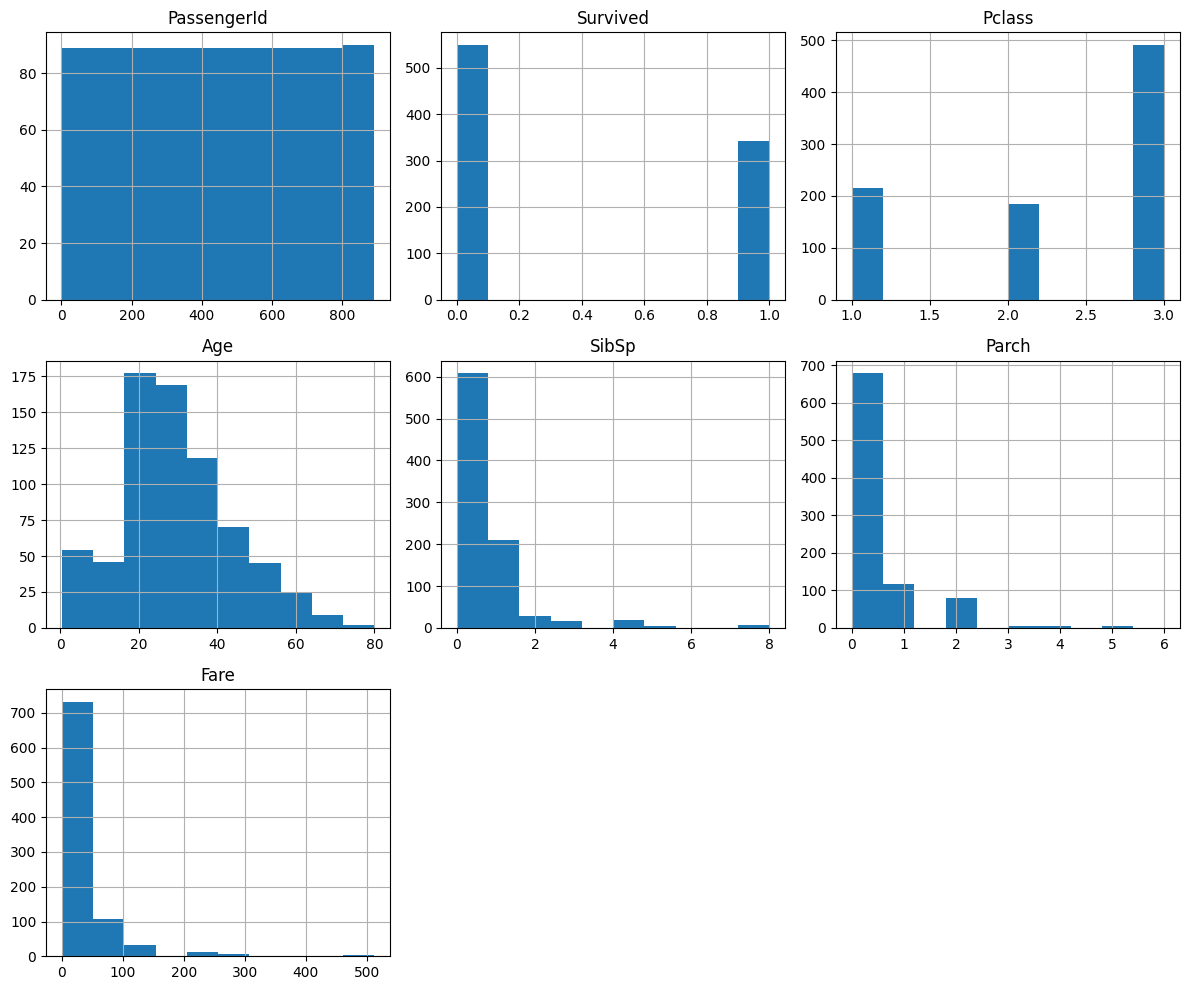

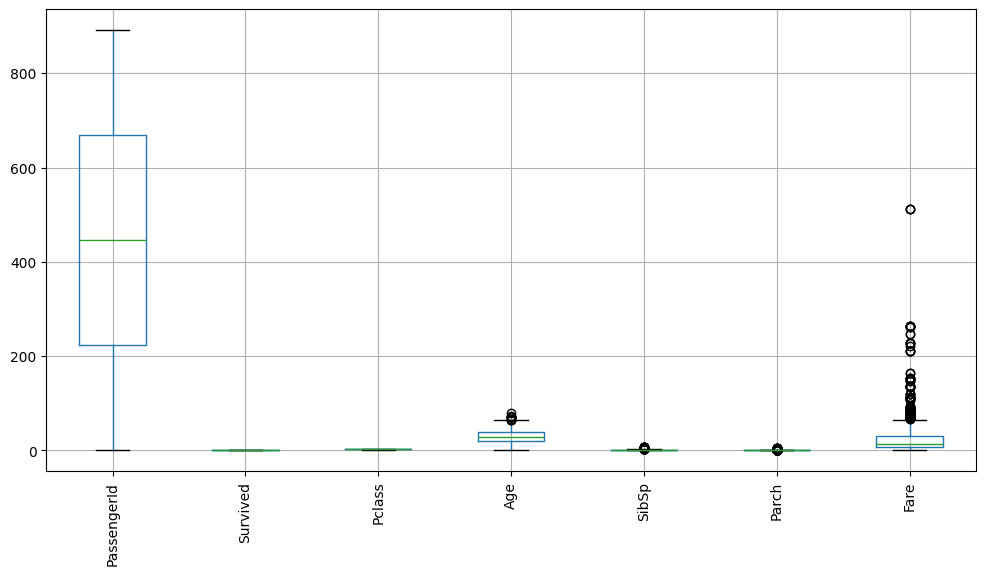

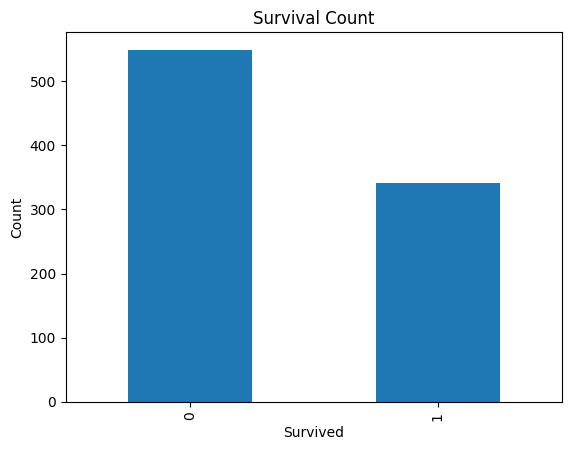

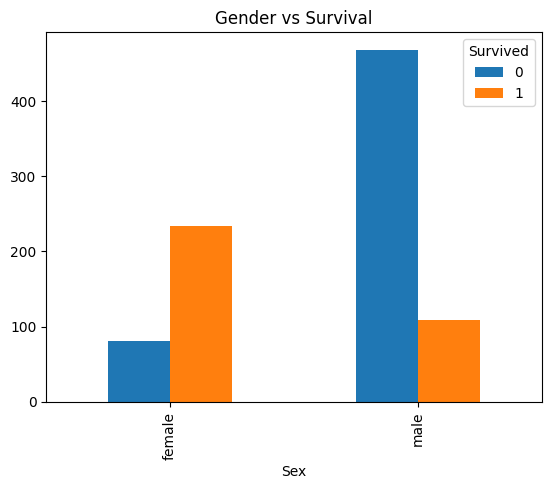

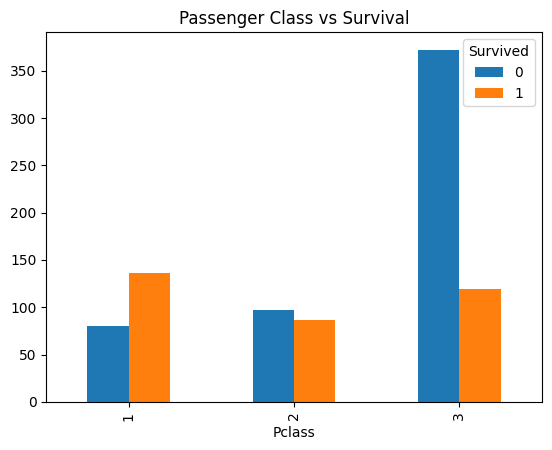

In [2]:
# Missing values
print(train_df.isnull().sum())

# Histograms
train_df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Boxplots
train_df.boxplot(figsize=(12,6))
plt.xticks(rotation=90)
plt.show()

# Survival Count
train_df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# Survival by Gender
pd.crosstab(train_df["Sex"], train_df["Survived"]).plot(kind="bar")
plt.title("Gender vs Survival")
plt.show()

# Survival by Passenger Class
pd.crosstab(train_df["Pclass"], train_df["Survived"]).plot(kind="bar")
plt.title("Passenger Class vs Survival")
plt.show()

This block performs Exploratory Data Analysis (EDA) to understand the dataset in greater detail. It checks for missing values in each feature and visualizes the distribution of numerical variables using histograms. Boxplots are used to identify outliers present in the dataset. Bar charts are created to analyze the distribution of passenger survival and to study the relationship between important categorical features such as gender and passenger class with the survival outcome. These visualizations help in identifying important patterns and provide valuable insights for building an effective predictive model.

In [3]:
# Save PassengerId
test_ids = test_df["PassengerId"]

# Drop unnecessary columns
drop_cols = ["PassengerId","Name","Ticket","Cabin"]

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

# Fill missing values
for df in [train_df, test_df]:
    df["Age"] = df["Age"].fillna(df["Age"].median())
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical columns
sex_encoder = LabelEncoder()
embarked_encoder = LabelEncoder()

train_df["Sex"] = sex_encoder.fit_transform(train_df["Sex"])
test_df["Sex"] = sex_encoder.transform(test_df["Sex"])

train_df["Embarked"] = embarked_encoder.fit_transform(train_df["Embarked"])
test_df["Embarked"] = embarked_encoder.transform(test_df["Embarked"])

# Features and Target
X = train_df.drop("Survived", axis=1)
y = train_df["Survived"]

# Split training data
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

This block prepares the dataset for machine learning by performing all the required preprocessing steps. Unnecessary columns such as Passenger ID, Name, Ticket, and Cabin are removed because they do not significantly contribute to prediction. Missing values in numerical and categorical features are replaced using suitable statistical methods such as median and mode. Categorical variables like Sex and Embarked are converted into numerical values using Label Encoding. Finally, the training dataset is divided into training and validation sets, while the testing dataset is prepared separately for making final predictions after model training.

In [4]:
# LightGBM Model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

# XGBoost Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

# Predictions
lgb_pred = lgbm.predict(X_valid)
xgb_pred = xgb.predict(X_valid)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


This block builds two powerful gradient boosting models: LightGBM and XGBoost. Both algorithms are initialized with appropriate parameters and trained using the preprocessed training dataset. After training, predictions are generated for the validation dataset. These models are widely used because they provide high prediction accuracy, handle complex relationships efficiently, and perform well on structured datasets. The generated predictions are later used to compare the performance of both algorithms.

In [5]:
def evaluate(name, y_true, pred):
    print("\n", name)
    print("Accuracy :", accuracy_score(y_true,pred))
    print("Precision:", precision_score(y_true,pred))
    print("Recall   :", recall_score(y_true,pred))
    print("F1 Score :", f1_score(y_true,pred))

evaluate("LightGBM", y_valid, lgb_pred)
evaluate("XGBoost", y_valid, xgb_pred)

# Hyperparameter Tuning
params = {
    "n_estimators":[50,100,150],
    "learning_rate":[0.05,0.1],
    "max_depth":[3,5,7]
}

grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("\nBest Parameters:",grid.best_params_)
print("Best Cross Validation Score:",grid.best_score_)


 LightGBM
Accuracy : 0.7988826815642458
Precision: 0.7619047619047619
Recall   : 0.6956521739130435
F1 Score : 0.7272727272727273

 XGBoost
Accuracy : 0.8100558659217877
Precision: 0.7536231884057971
Recall   : 0.7536231884057971
F1 Score : 0.7536231884057971
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

This block evaluates the performance of both LightGBM and XGBoost models using important classification metrics such as Accuracy, Precision, Recall, and F1-Score. These metrics provide a complete understanding of the model's predictive capability beyond simple accuracy. In addition, GridSearchCV is applied to perform hyperparameter tuning on the LightGBM model by testing multiple combinations of parameters through cross-validation. This process helps identify the optimal parameter settings, resulting in improved model performance and better generalization on unseen data.

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.798883   0.761905  0.695652  0.727273
1   XGBoost  0.810056   0.753623  0.753623  0.753623


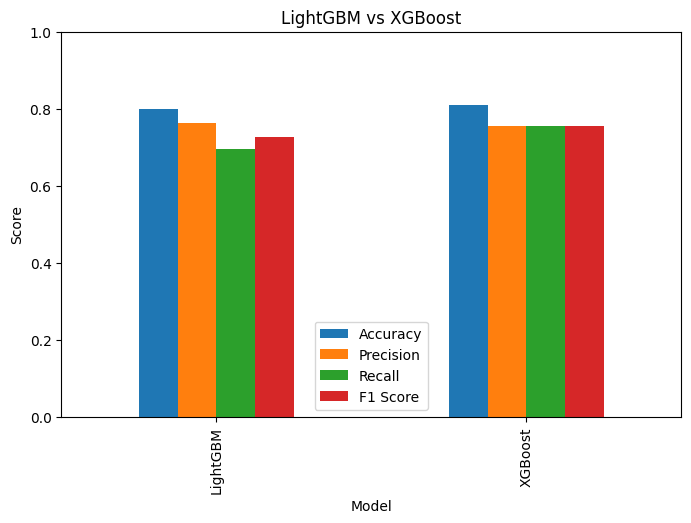


Submission File Created Successfully!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


In [6]:
results = pd.DataFrame({
    "Model":["LightGBM","XGBoost"],
    "Accuracy":[
        accuracy_score(y_valid,lgb_pred),
        accuracy_score(y_valid,xgb_pred)
    ],
    "Precision":[
        precision_score(y_valid,lgb_pred),
        precision_score(y_valid,xgb_pred)
    ],
    "Recall":[
        recall_score(y_valid,lgb_pred),
        recall_score(y_valid,xgb_pred)
    ],
    "F1 Score":[
        f1_score(y_valid,lgb_pred),
        f1_score(y_valid,xgb_pred)
    ]
})

print(results)

# Comparison Graph
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("LightGBM vs XGBoost")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

# Predict on Titanic Test Dataset
test_predictions = lgbm.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("\nSubmission File Created Successfully!")
print(submission.head())

This block performs the comparative analysis between LightGBM and XGBoost by storing their evaluation metrics in a comparison table and visualizing the results using a bar chart. The graphical representation makes it easier to compare the strengths and weaknesses of both models. Finally, the optimized LightGBM model is used to predict the survival of passengers in the Titanic testing dataset. The predicted results are saved into a submission.csv file, which can be used for evaluation or competition submission.

## **Conclusion**
In this assignment, the Titanic dataset was successfully analyzed using Exploratory Data Analysis (EDA), data preprocessing, and two advanced machine learning algorithms: LightGBM and XGBoost. Missing values were handled, unnecessary features were removed, and categorical variables were encoded to prepare the data for model training. Both models were trained and evaluated using important performance metrics such as Accuracy, Precision, Recall, and F1-Score, providing a comprehensive comparison of their predictive capabilities.

Hyperparameter tuning with GridSearchCV further improved the performance of the LightGBM model by selecting the optimal parameter values. The comparative analysis showed that both LightGBM and XGBoost achieved high prediction accuracy and performed effectively on the Titanic dataset. LightGBM offered faster training and efficient computation, while XGBoost produced robust and reliable predictions. Overall, this assignment demonstrated that both algorithms are powerful ensemble learning techniques and are well suited for solving real-world classification problems such as predicting passenger survival.